In [4]:
! pip install pandas numpy matplotlib sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [5]:

import numpy as np
import matplotlib.pyplot as plt

In [6]:
! pip install pandas
import pandas as pd

In [7]:
df = pd.read_csv(r"C:\Users\suraj\Downloads\Spam_Classifier\spam.csv")

In [8]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [9]:
#1)data cleaning

df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis = 1 , inplace = True)

In [10]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df.drop_duplicates()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [13]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(5169, 2)

In [17]:
df.isnull().sum()

v1    0
v2    0
dtype: int64

In [18]:
df.rename(columns={"v1" : "Target", "v2" : "Text"}, inplace = True)

In [19]:
df

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [20]:
df = df.reset_index()

In [21]:
df

,index,Target,Text
0,0,ham,"Go until jurong point, crazy.. Available only ..."
1,1,ham,Ok lar... Joking wif u oni...
2,2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,ham,U dun say so early hor... U c already then say...
4,4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...,...
5164,5567,spam,This is the 2nd time we have tried 2 contact u...
5165,5568,ham,Will Ì_ b going to esplanade fr home?
5166,5569,ham,"Pity, * was in mood for that. So...any other s..."
5167,5570,ham,The guy did some bitching but I acted like i'd...


In [22]:
! pip install scikit-learn

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [24]:
df["Target"] = encoder.fit_transform(df["Target"])

In [25]:
df

,index,Target,Text
0,0,0,"Go until jurong point, crazy.. Available only ..."
1,1,0,Ok lar... Joking wif u oni...
2,2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,3,0,U dun say so early hor... U c already then say...
4,4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...,...
5164,5567,1,This is the 2nd time we have tried 2 contact u...
5165,5568,0,Will Ì_ b going to esplanade fr home?
5166,5569,0,"Pity, * was in mood for that. So...any other s..."
5167,5570,0,The guy did some bitching but I acted like i'd...


In [26]:
df = df.drop("index", axis = 1)

In [27]:
df

,Target,Text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5164,1,This is the 2nd time we have tried 2 contact u...
5165,0,Will Ì_ b going to esplanade fr home?
5166,0,"Pity, * was in mood for that. So...any other s..."
5167,0,The guy did some bitching but I acted like i'd...


In [28]:
#2)EDA

df['Target'].value_counts()

Target
0    4516
1     653
Name: count, dtype: int64

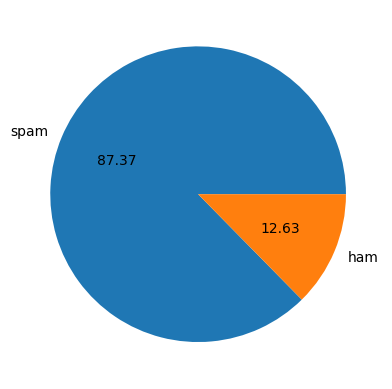

In [29]:
#visualization

plt.pie(df['Target'].value_counts(), labels=['spam', 'ham'], autopct="%0.2f")
plt.show()

# insight >> Data is Imblanced means spam data is more higher than ham data

In [30]:
#3 >> NLTK >> Text Pre-Processing

! pip install nltk

In [31]:
import nltk

In [32]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\suraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [33]:
# add new col where we have tottal characters are present
df["character_len"] = df["Text"].apply(len)

In [34]:
df

,Target,Text,character_len
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5164,1,This is the 2nd time we have tried 2 contact u...,161
5165,0,Will Ì_ b going to esplanade fr home?,37
5166,0,"Pity, * was in mood for that. So...any other s...",57
5167,0,The guy did some bitching but I acted like i'd...,125


In [35]:
#add new col of count of unique words

df["num_words"] = df['Text'].apply(lambda x : len(nltk.word_tokenize(x)))

In [36]:
df.drop("unique_words", axis = 1, inplace = True)

KeyError: "['unique_words'] not found in axis"

In [37]:
df

,Target,Text,character_len,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5164,1,This is the 2nd time we have tried 2 contact u...,161,35
5165,0,Will Ì_ b going to esplanade fr home?,37,9
5166,0,"Pity, * was in mood for that. So...any other s...",57,15
5167,0,The guy did some bitching but I acted like i'd...,125,27


In [38]:
df['num_sentence'] = df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [39]:
df

,Target,Text,character_len,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5164,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5165,0,Will Ì_ b going to esplanade fr home?,37,9,1
5166,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5167,0,The guy did some bitching but I acted like i'd...,125,27,1


In [40]:
#metadata

df.describe()

,Target,character_len,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.978332,18.455794,1.965564
std,0.332253,58.236795,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [41]:
#five point summary of only ham data 

df[df['Target']==0].describe()

,Target,character_len,num_words,num_sentence
count,4516.0,4516.000000,4516.000000,4516.000000
mean,0.0,70.459699,17.123782,1.820195
std,0.0,56.358868,13.493970,1.383657
min,0.0,2.000000,1.000000,1.000000
25%,0.0,34.000000,8.000000,1.000000
50%,0.0,52.000000,13.000000,1.000000
75%,0.0,90.000000,22.000000,2.000000
max,0.0,910.000000,220.000000,38.000000


In [42]:
#visualization
! pip install seaborn
import seaborn as sns
! pip install numpy==1.24.4


  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "C:\Users\suraj\miniconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\suraj\miniconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\suraj\miniconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
        File "C:\Users\suraj\miniconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 70, in _build_backend
          obj = import_module(mod_path)


<Axes: xlabel='character_len', ylabel='Count'>

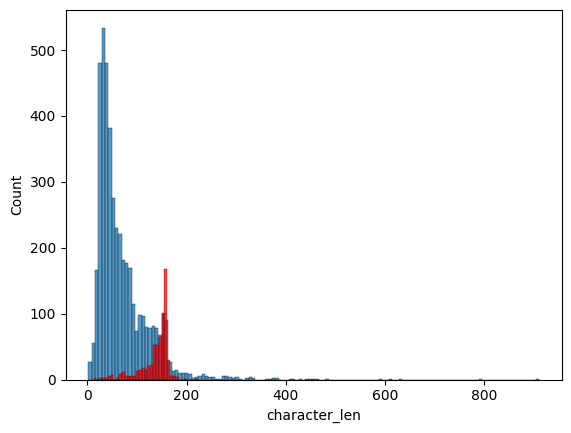

In [43]:
sns.histplot(df[df['Target']==0]['character_len'])
sns.histplot(df[df['Target']==1]['character_len'], color = "red")

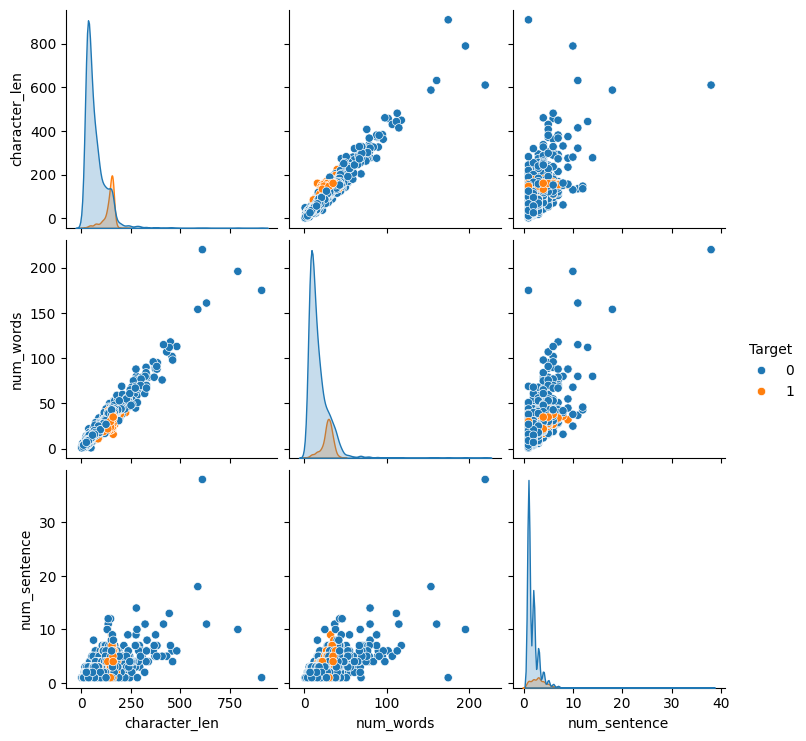

In [44]:
sns.pairplot(df, hue = 'Target')

<Axes: >

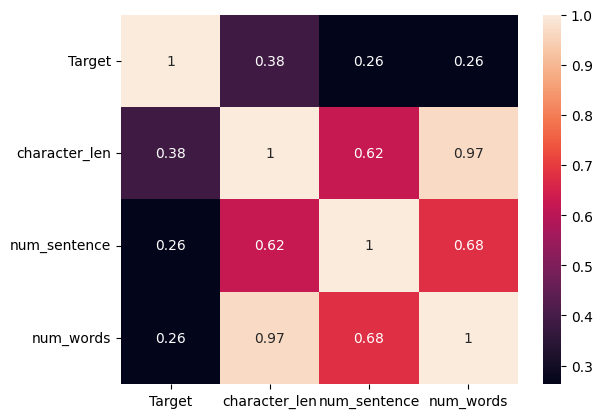

In [45]:
sns.heatmap(df[["Target", "character_len", "num_sentence", "num_words"]].corr(), annot = True)

# Data Preprocessing steps
* lowercase
* tokenize
* remove the special characters like , $ . !
* stopword
* punctuation
* stemming
* lemitization

In [46]:
#stopwords
from nltk.corpus import stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\suraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [47]:
#stemming

from nltk.stem.porter import PorterStemmer
stemmer = PorterStemmer()

In [48]:
import string

In [49]:
def transform_text(text):
    text = text.lower()   # text lowercasing
    text = nltk.word_tokenize(text)   # text tokenization

    y = []

    for i in text:
        if i.isalnum:   #if character is alpha-numeric 
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:       #stop words removal
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text = y[:]
    y.clear()

    for i in text:           #stemming
        y.append(stemmer.stem(i))

    return " ".join(y)

In [50]:
transform_text("i am too busy, i cannot take the meeting right now.")

'busi take meet right'

In [51]:
df['transformed_text'] = df['Text'].apply(transform_text)

In [52]:
! pip install wordcloud
import wordcloud 
#wordcloud >> means way to represent the text data

In [53]:
from wordcloud import WordCloud  

word_cloud = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [54]:
spam_word_cloud = word_cloud.generate(df[df['Target']==1]['transformed_text'].str.cat(sep=" "))

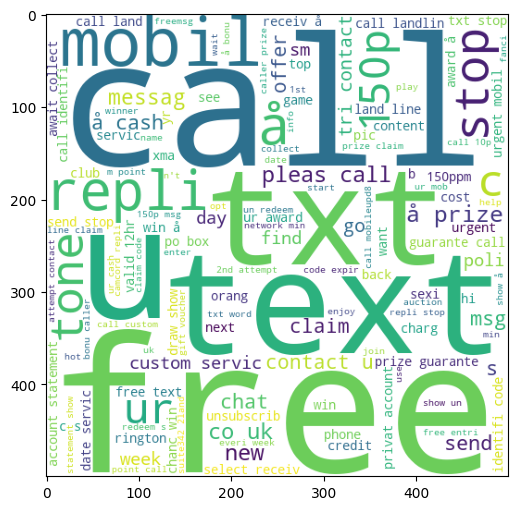

In [55]:
#visualize 

plt.figure(figsize=(15,6))
plt.imshow(spam_word_cloud)
# bigger size of texts means it repates many time and smaller means less repeater

In [56]:
ham_word_cloud = word_cloud.generate(df[df['Target']==0]['transformed_text'].str.cat(sep=" "))

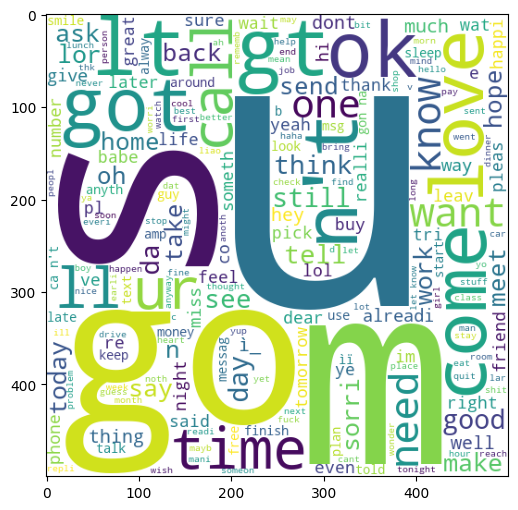

In [57]:
#visualize 

plt.figure(figsize=(15,6))
plt.imshow(ham_word_cloud)
# bigger size of texts means it repates many time and smaller means less repeater

In [58]:
spam_corpus = []

for msg in df[df['Target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [59]:
len(spam_corpus)

11083

In [60]:
ham_corpus = []

for msg in df[df['Target']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

# Model Building

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

Count_Vectorizer = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)  #use for encoding the data

In [62]:


import numpy as np


In [63]:
x = tfidf.fit_transform(df['transformed_text']).toarray()

In [64]:
x.shape

(5169, 3000)

In [65]:
y = df["Target"].values

In [66]:
#split the data train test

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=2)

In [67]:
#model training

from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB


In [68]:
GNB = GaussianNB()
BNB = BernoulliNB()
MNB = MultinomialNB()

In [69]:
GNB.fit(x_train, y_train)
BNB.fit(x_train, y_train)
MNB.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [70]:
#performance or evaluation  metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [71]:
#accuracy for GNB
y_pred1 = GNB.predict(x_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8800773694390716
[[789 107]
 [ 17 121]]
0.5307017543859649


In [72]:
#accuracy for BNB
y_pred2 = BNB.predict(x_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.988394584139265
[[896   0]
 [ 12 126]]
1.0


In [73]:
#accuracy for MNB
y_pred3 = MNB.predict(x_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9758220502901354
[[896   0]
 [ 25 113]]
1.0


In [76]:
#download the model

import pickle

pickle.dump(tfidf, open('vectorizer.pkl', "wb"))
pickle.dump(MNB, open('model.pkl', "wb"))